# Sleep and Wellbeing Analysis

By Connor Sherrill

Simple grouped analysis of sleep duration vs anxiety, depression, and positive mental health.

These results show that wellbeing increases with sleep but plateaus around 7+ hours.

## Load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

data_path = Path("data.csv")
if not data_path.exists():
    data_path = Path("../data.csv")

df = pd.read_csv(data_path, low_memory=False)

## Preview first rows (relevant fields)

In [2]:
preview_cols = [
    "responseid",
    "Finished",
    "sleep_wknight",
    "sleep_wkend",
    "deprawsc",
    "anx_score",
    "positiveMH",
]

df[preview_cols].head(8)

,responseid,Finished,sleep_wknight,sleep_wkend,deprawsc,anx_score,positiveMH
0,R_1TGFyxLOqW1PZnL,1,3.0,3.0,24.0,13.0,0.0
1,R_3WBLeqnaO3RsWxr,0,NaN,NaN,8.0,7.0,0.0
2,R_3lz7HbBX7qZq3mG,0,NaN,NaN,NaN,NaN,NaN
3,R_6cwKNvO8lKIh8NX,1,6.0,8.0,8.0,9.0,0.0
4,R_5lVSZKBrDqkU8UV,0,NaN,NaN,NaN,NaN,NaN
5,R_7w9f60E1fWwG837,1,7.0,8.0,6.0,6.0,1.0
6,R_34tPgzoRLnCoBFF,1,NaN,NaN,7.0,14.0,0.0
7,R_6QFwXqCfUK9oJEX,0,NaN,NaN,NaN,NaN,NaN


## Build analysis dataset

In [3]:
analysis = df[[
    "Finished",
    "sleep_wknight",
    "sleep_wkend",
    "deprawsc",
    "anx_score",
    "positiveMH",
]].copy()

for col in analysis.columns:
    analysis[col] = pd.to_numeric(analysis[col], errors="coerce")

analysis = analysis[analysis["Finished"] == 1].copy()
analysis["avg_sleep"] = (5 * analysis["sleep_wknight"] + 2 * analysis["sleep_wkend"]) / 7
analysis = analysis[(analysis["avg_sleep"] >= 1) & (analysis["avg_sleep"] <= 10)]

analysis["sleep_group"] = pd.cut(
    analysis["avg_sleep"],
    bins=[0, 6, 7, 8, 10],
    labels=["<6h", "6-7h", "7-8h", "8h+"],
    include_lowest=True,
)

analysis = analysis.dropna(subset=["sleep_group", "deprawsc", "anx_score", "positiveMH"])
print(f"Rows used in analysis: {len(analysis):,}")

Rows used in analysis: 27,934


## Method: grouped summary by sleep duration

In [4]:
summary = (
    analysis.groupby("sleep_group", observed=True)
    .agg(
        n=("avg_sleep", "size"),
        avg_week_sleep=("avg_sleep", "mean"),
        mean_deprawsc=("deprawsc", "mean"),
        mean_anx_score=("anx_score", "mean"),
        positiveMH_rate=("positiveMH", "mean"),
    )
    .round(3)
)

summary["positiveMH_rate"] = (summary["positiveMH_rate"] * 100).round(1)
print(summary.to_string())

corrs = analysis[["avg_sleep", "deprawsc", "anx_score", "positiveMH"]].corr(numeric_only=True)["avg_sleep"]
print("\nCorrelation with avg_sleep:")
print(corrs.round(3).to_string())

                n  avg_week_sleep  mean_deprawsc  mean_anx_score  positiveMH_rate
sleep_group                                                                      
<6h          7597           5.343         10.997           9.473             28.9
6-7h         9717           6.631          7.738           7.162             40.4
7-8h         5915           7.292          6.504           6.313             45.7
8h+          4705           8.656          6.576           6.214             47.1

Correlation with avg_sleep:
avg_sleep     1.000
deprawsc     -0.292
anx_score    -0.226
positiveMH    0.142


## Plot sleep-group differences

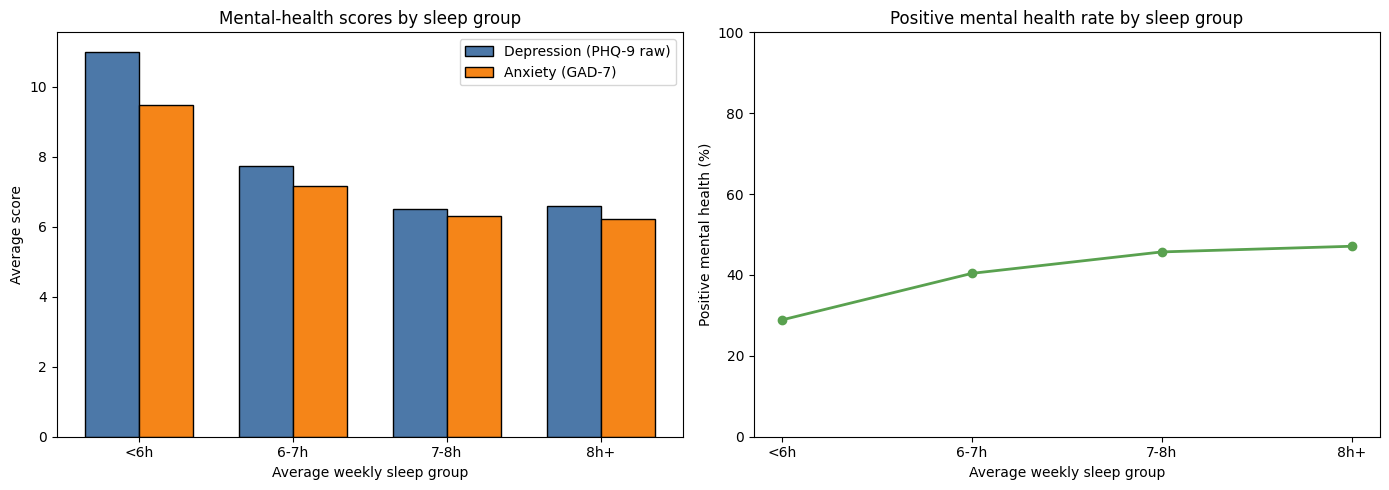

In [5]:
x_labels = summary.index.astype(str).tolist()
x = np.arange(len(x_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width / 2, summary["mean_deprawsc"], width=width, label="Depression (PHQ-9 raw)", color="#4C78A8", edgecolor="black")
axes[0].bar(x + width / 2, summary["mean_anx_score"], width=width, label="Anxiety (GAD-7)", color="#F58518", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels)
axes[0].set_xlabel("Average weekly sleep group")
axes[0].set_ylabel("Average score")
axes[0].set_title("Mental-health scores by sleep group")
axes[0].legend()

axes[1].plot(x_labels, summary["positiveMH_rate"], marker="o", linewidth=2, color="#59A14F")
axes[1].set_xlabel("Average weekly sleep group")
axes[1].set_ylabel("Positive mental health (%)")
axes[1].set_title("Positive mental health rate by sleep group")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Scatter + trend line (sleep vs depression)

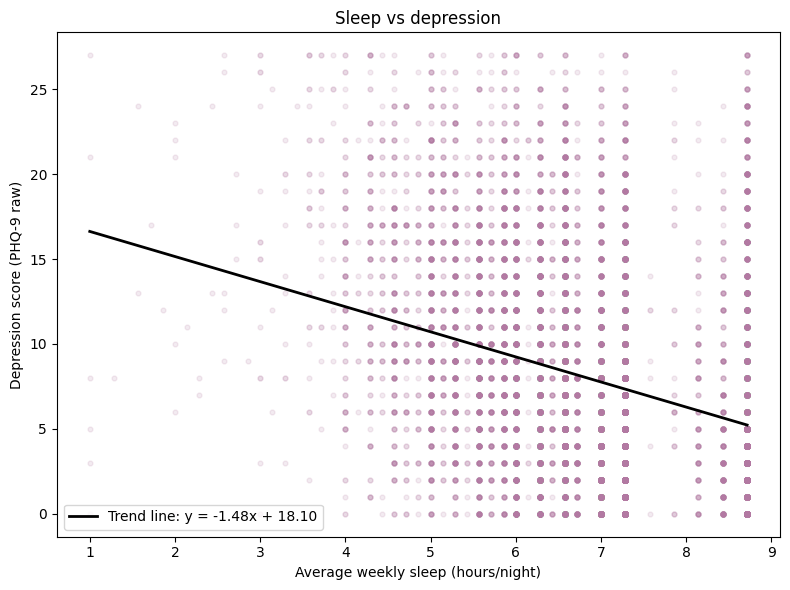

In [6]:
plot_df = analysis[["avg_sleep", "deprawsc"]].dropna()
if len(plot_df) > 12000:
    plot_df = plot_df.sample(12000, random_state=42)

m, b = np.polyfit(plot_df["avg_sleep"], plot_df["deprawsc"], 1)
x_line = np.linspace(plot_df["avg_sleep"].min(), plot_df["avg_sleep"].max(), 100)

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["avg_sleep"], plot_df["deprawsc"], alpha=0.15, s=12, color="#B279A2")
plt.plot(x_line, m * x_line + b, color="black", linewidth=2, label=f"Trend line: y = {m:.2f}x + {b:.2f}")
plt.xlabel("Average weekly sleep (hours/night)")
plt.ylabel("Depression score (PHQ-9 raw)")
plt.title("Sleep vs depression")
plt.legend()
plt.tight_layout()
plt.show()